In [15]:
import pandas as pd
import json
from pathlib import Path
from elasticsearch import Elasticsearch, helpers
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import Markdown, display
import subprocess

In [18]:
BASE_DIR = Path.cwd()                        
DATA_DIR = BASE_DIR 
CSV_PATH = DATA_DIR / "documents.csv"
JSONL_PATH = DATA_DIR / "documents.jsonl"
QUERIES_PATH = DATA_DIR / "queries.csv"
QRELS_PATH = DATA_DIR / "qrels.csv"

In [19]:
# Load CSV File
try:
    df = pd.read_csv(CSV_PATH, encoding="utf-8")
except FileNotFoundError:
    raise SystemExit(f"File not found: {CSV_PATH}")
except Exception as e:
    raise SystemExit(f"Error reading CSV: {e}")

In [20]:
# Display Columns and Document Count
print(f"CSV loaded successfully → {len(df)} documents found")
print(f"Columns detected: {list(df.columns)}")

CSV loaded successfully → 18316 documents found
Columns detected: ['ID', 'Text']


In [21]:
# Validate Required Columns
required_cols = {"ID", "Text"}
missing = required_cols - set(df.columns)
if missing:
    raise SystemExit(f"Missing expected columns: {missing}")

In [22]:
def preprocess(s):
    if not isinstance(s, str):
        return ""
    s = s.strip()
    s = re.sub(r"\s+", " ", s)                       # collapse spaces/newlines
    s = re.sub(r"http\S+|www\.\S+", "<URL>", s)      # replace URLs
    s = re.sub(r"\S+@\S+", "<EMAIL>", s)             # replace emails
    s = re.sub(r"<[^>]+>", " ", s)                   # remove HTML tags
    s = ''.join(ch for ch in s if ord(ch) >= 32)     # remove control chars
    s = re.sub(r"['\"]", "", s)                      # remove single and double quotes
    return s.strip()


df = df.dropna(subset=["Text"])
df["Text"] = df["Text"].astype(str).map(preprocess)

In [23]:
# Convert to JSONL
records_written = 0
with open(JSONL_PATH, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        record = {
            "id": row["ID"],     
            "text": row["Text"]
        }
        json_line = json.dumps(record, ensure_ascii=False)
        f.write(json_line + "\n")
        records_written += 1

print(f"Converted {records_written} rows → JSONL format")
print(f"Output saved at: {JSONL_PATH.resolve()}")

Converted 18316 rows → JSONL format
Output saved at: C:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\documents.jsonl


In [24]:
class Search:
    def __init__(self):
        self.es = Elasticsearch("http://127.0.0.1:9200")
        client_info = self.es.info()
        print('Connected to Elasticsearch!')
        pprint(client_info.body)

    #Return instance
    def get_es(self):
        return self.es

    #Creates empty index with the parameters we feed
    def create_index(self):
        index_settings = {
            "settings": {
                "similarity": {
                    "default": {"type": "BM25"}
                },
                "analysis": {
                    "analyzer": {
                        "default": {
                            "type": "standard"
                        }
                    }
                }
            },
            "mappings": {
                "properties": {
                    "id": {"type": "keyword"},
                    "text": {"type": "text", "analyzer": "standard"}
                }
            }
        }

        self.es.indices.create(index='ir2025', body=index_settings)
        print("Index created with English analyzer and BM25 similarity.")

    #Insert single document
    def insert_document(self, document):
        return self.es.index(index='ir2025', document=document)

    #Insert multiple indexes
    def insert_documents(self, documents):
        operations = []
        for document in documents:
            operations.append({'index': {'_index': 'ir2025'}})
            operations.append(document)

        result = self.es.bulk(operations=operations)
        print("Insertion finished.")
        print(result)

    #Deletes index
    def delete_index(self, index_name="ir2025"):
        if self.es.indices.exists(index=index_name):
            self.es.indices.delete(index=index_name)
            print(f"Index '{index_name}' deleted successfully.")
        else:
            print(f"Index '{index_name}' does not exist.")

    #Check if index exists
    def exists(self, index_name="ir2025"):
        try:
            return self.es.indices.exists(index=index_name)
        except Exception as e:
            print(f"Error checking if index exists: {e}")
            return False

    #Helper function for bulk indexing
    def generate_actions(self, jsonl_path, index_name):
        with open(jsonl_path, encoding="utf-8") as f:
            for i, line in enumerate(f):
                yield {
                    "_index": index_name,
                    "_id": i,
                    "_source": json.loads(line)
                }

    #Bulk index docs
    def index_documents(self, jsonl_path, index_name):
        actions = self.generate_actions(jsonl_path, index_name)
        success, _ = helpers.bulk(self.get_es(), actions)
        print(f"Successfully indexed {success} documents into '{index_name}'")

    #Runs query
    def search_query(self, query_text, k=10, index_name="ir2025"):
        try:
            resp = self.es.search(
                index=index_name,
                query={"match": {"text": {"query": query_text}}},
                size=k
            )
            return resp["hits"]["hits"]
        except Exception as e:
            print(f"Error executing search query: {e}")
            return []


# ------------------------------------------------------------------
class Evaluation:
    def __init__(self, search_client):
        self.search = search_client
        
    #Loads file
    def load_file(self, filename):
        df = pd.read_csv(filename, encoding="utf-8")
        print("Loaded queries successfully")
        return df

    #Runs queries and keep results
    def generate_file_results(self, dir, filename):
        df_queries = self.load_file(filename)
        for k in [20, 30, 50]:
            results_path = dir / f"results_{k}.txt"
            with open(results_path, "w", encoding="utf-8") as f:
                for _, row in df_queries.iterrows():
                    qid = str(row[0]) 
                    qtext = str(row[1])
                    
                    results = self.search.search_query(qtext, k) 
                    
                    for rank, hit in enumerate(results, start=1):
                        docid = hit["_source"]["id"]
                        score = hit["_score"]
                        f.write(f"{qid} Q0 {docid} {rank} {score:.4f} BM25\n")
            print(f"Created results file: {results_path}")

    #Load qrels file
    def load_qrels(self, path):
        return pd.read_csv(
            path,
            sep=";",
            header=0,
            encoding="utf-8-sig",
            names=["qid", "_", "docid", "rel"]
        )

    #Load results
    def load_results(self, path):
        return pd.read_csv(path, sep=r"\s+", header=None, names=["qid", "_", "docid", "rank", "score", "method"])

    #Calculates precision
    def precision_at_k(self, results, qrels, k):
        precisions = []
        for qid, group in results.groupby("qid"):
            rel_docs = set(qrels[qrels["qid"] == qid]["docid"])
            retrieved = group.sort_values("rank").head(k)
            hits = sum(doc in rel_docs for doc in retrieved["docid"])
            precisions.append(hits / k)
        return sum(precisions) / len(precisions)

    #Calculates MAP
    def mean_average_precision(self, results, qrels):
        APs = []
        for qid, group in results.groupby("qid"):
            rel_docs = set(qrels[qrels["qid"] == qid]["docid"])
            if not rel_docs: 
                continue
            retrieved = group.sort_values("rank")
            hits, cum_prec = 0, 0.0
            for i, doc in enumerate(retrieved["docid"], 1):
                if doc in rel_docs:
                    hits += 1
                    cum_prec += hits / i
            if hits > 0:
                APs.append(cum_prec / hits)
        return sum(APs) / len(APs) if APs else 0.0

    #Loads and displayes results
    def evaluate_results(self, qrels, DATA_DIR):
        """
        Loads result files, calculates metrics,
        and displays them in a formatted markdown table (no console spam).
        """
        all_results = {
            "Retrieval_k": [],
            "P@5": [], "P@10": [], "P@15": [], "P@20": [],
            "MAP": []
        }
        
        k_eval_values = [5, 10, 15, 20]

        for k_max in [20, 30, 50]:
            results_path = DATA_DIR / f"results_{k_max}.txt"
            results = self.load_results(results_path)

            all_results["Retrieval_k"].append(k_max)

            for k_eval in k_eval_values:
                p = self.precision_at_k(results, qrels, k_eval)
                all_results[f"P@{k_eval}"].append(p)

            map_val = self.mean_average_precision(results, qrels)
            all_results["MAP"].append(map_val)
            
        df_results = pd.DataFrame(all_results)

        # Pretty Markdown Output
        display(Markdown("### **IR Evaluation Results**"))
        display(Markdown(df_results.to_markdown(index=False)))

        return df_results


In [25]:
def fix_and_write_qrels(qrels_csv_path: Path, out_path: Path, sample_results_path: Path = None):
    """
    Διαβάζει το qrels csv (autodetect sep), βρίσκει στήλες qid/docid/rel με heuristics,
    και γράφει σωστά qrels στον out_path με μορφή: qid 0 docid rel
    (αποφεύγει γραμμές όπου docid == 'Q0' ή κενά).
    """
    dfq = pd.read_csv(qrels_csv_path, sep=None, engine='python', encoding="utf-8-sig")
    dfq = dfq.dropna(how='all')
    dfq = dfq.astype(str).applymap(lambda x: x.strip())
    cols = list(dfq.columns)

    # collect sample docids from results to help pick docid column
    res_docids = set()
    if sample_results_path and sample_results_path.exists():
        with open(sample_results_path, encoding="utf-8", errors="replace") as f:
            for ln in f:
                parts = re.split(r"\s+", ln.strip())
                if len(parts) >= 3:
                    res_docids.add(parts[2])

    # score columns: intersection with result docids, and numeric-looking values
    candidates = []
    for c in cols:
        vals = dfq[c].dropna().astype(str).str.strip().unique()[:200].tolist()
        inter = len(set(vals) & res_docids) if res_docids else 0
        num_like = sum(1 for v in vals if re.match(r"^\d+$", v))
        candidates.append((c, inter, num_like, vals[:5]))

    # pick docid column as one with max intersection or numeric-like
    docid_col = max(candidates, key=lambda x: (x[1], x[2]))[0]
    # pick rel column as first numeric-like that's not qid/docid, else last different column
    qid_col = cols[0]
    rel_col = None
    for c, inter, num_like, vals in candidates:
        if c in (qid_col, docid_col): continue
        sample_vals = dfq[c].dropna().astype(str).str.strip().unique()[:50].tolist()
        if sample_vals and all(re.match(r"^\d+$", v) for v in sample_vals):
            rel_col = c
            break
    if rel_col is None:
        others = [c for c in cols if c not in (qid_col, docid_col)]
        rel_col = others[-1] if others else cols[-1]

    # write fixed qrels
    with open(out_path, "w", encoding="utf-8") as out:
        for _, row in dfq.iterrows():
            qid = str(row[qid_col]).strip()
            docid = str(row[docid_col]).strip()
            rel = str(row[rel_col]).strip()
            if not qid or not docid or docid.upper() == "Q0":
                continue
            out.write(f"{qid} 0 {docid} {rel}\n")

    print(f"Wrote fixed qrels -> {out_path} (qid_col={qid_col}, docid_col={docid_col}, rel_col={rel_col})")

def run_trec_eval_only(qrels_fixed_path: Path, data_dir: Path, trec_bin_path: Path):
    """
    Τρέχει αποκλειστικά το trec_eval.exe για κάθε results_k (20,30,50).
    Αν οποιοδήποτε run επιστρέψει non-zero, τυπώνει stderr και τερματίζει με SystemExit.
    Επιστρέφει DataFrame με περίληψη metrics (P@5,10,15,20, MAP) για κάθε results_k.
    """
    if not trec_bin_path.exists():
        raise SystemExit(f"trec_eval binary not found at {trec_bin_path}. Το πρόγραμμα απαιτεί το trec_eval.exe.")

    trec_summary = []
    for k in [20,30,50]:
        results_file = data_dir / f"results_{k}.txt"
        if not results_file.exists():
            print(f"Missing results file: {results_file}, skipping.")
            continue
        cmd = [str(trec_bin_path), str(qrels_fixed_path), str(results_file), '-m', 'map', '-m', 'P.5', '-m', 'P.10', '-m', 'P.15', '-m', 'P.20']
        proc = subprocess.run(cmd, capture_output=True, text=True)
        if proc.returncode != 0:
            print(f"trec_eval failed for results_{k}.txt (rc={proc.returncode})")
            print("=== trec_eval stderr ===")
            print(proc.stderr)
            raise SystemExit(f"trec_eval failed for results_{k}.txt (see stderr above).")
        out = proc.stdout.strip()
        parsed = {}
        for line in out.splitlines():
            parts = re.split(r"\s+", line.strip())
            if len(parts) >= 3:
                metric = parts[0]
                value = parts[-1]
                try:
                    parsed[metric] = float(value)
                except:
                    parsed[metric] = None
        trec_summary.append({
            "retrieval_k": k,
            "P@5": parsed.get("P_5", parsed.get("P.5", None)),
            "P@10": parsed.get("P_10", parsed.get("P.10", None)),
            "P@15": parsed.get("P_15", parsed.get("P.15", None)),
            "P@20": parsed.get("P_20", parsed.get("P.20", None)),
            "MAP": parsed.get("map", None)
        })

    return pd.DataFrame(trec_summary)


In [26]:
#Initiate search class and index name
search=Search()
INDEX_NAME = "ir2025" 

Connected to Elasticsearch!
{'cluster_name': 'elasticsearch',
 'cluster_uuid': 'LhE-1-1hSHGWtwOEbrNFSA',
 'name': 'PPAVLOU',
 'tagline': 'You Know, for Search',
 'version': {'build_date': '2025-09-16T22:05:19.073893347Z',
             'build_flavor': 'default',
             'build_hash': '0b7fe68d2e369469ff9e9f344ab6df64ab9c5293',
             'build_snapshot': False,
             'build_type': 'zip',
             'lucene_version': '10.2.2',
             'minimum_index_compatibility_version': '8.0.0',
             'minimum_wire_compatibility_version': '8.19.0',
             'number': '9.1.4'}}


In [27]:
#Delete index if exists
if search.exists(INDEX_NAME):
    search.delete_index(index_name=INDEX_NAME)
    
#Create new empty index
search.create_index()

#Index docs
search.index_documents(JSONL_PATH,INDEX_NAME)

Index 'ir2025' deleted successfully.
Index created with English analyzer and BM25 similarity.
Successfully indexed 18316 documents into 'ir2025'


In [28]:
#Create evaluation class
evaluate=Evaluation(search)

#Generate results
evaluate.generate_file_results(DATA_DIR,QUERIES_PATH)

#Load qrels file
qrels = evaluate.load_qrels(QRELS_PATH)

# Evaluate Results (existing in-python metrics)
dynamic_df=evaluate.evaluate_results(qrels=qrels,DATA_DIR=DATA_DIR)


Loaded queries successfully


C:\Users\perik\AppData\Local\Temp\ipykernel_17296\469134939.py:117: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  qid = str(row[0])
C:\Users\perik\AppData\Local\Temp\ipykernel_17296\469134939.py:118: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  qtext = str(row[1])


Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_20.txt
Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_30.txt
Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_50.txt


### **IR Evaluation Results**

|   Retrieval_k |   P@5 |   P@10 |     P@15 |   P@20 |      MAP |
|--------------:|------:|-------:|---------:|-------:|---------:|
|            20 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.805159 |
|            30 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.763954 |
|            50 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.70481  |

In [31]:
# -------------------------- trec_eval (ONLY) runner & parser --------------------------
import subprocess, re
from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025")
TRECEVAL_BIN = DATA_DIR / "trec_eval" / "trec_eval.exe"   # προσαρμογή αν χρειαστεί
RESULT_KS = [20, 30, 50]
OUT_SUM = DATA_DIR / "trec_eval_summary.txt"

if not TRECEVAL_BIN.exists():
    raise SystemExit(f"trec_eval binary not found: {TRECEVAL_BIN}")

def run_all_trec(qrels_path: Path, results_path: Path):
    """Run trec_eval -m all_trec and return stdout (text)."""
    cmd = [str(TRECEVAL_BIN), str(qrels_path), str(results_path), '-m', 'all_trec']
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
    if proc.returncode != 0:
        # show stderr to help debugging and then stop
        print("trec_eval returned non-zero exit code:", proc.returncode)
        print("stderr:\n", proc.stderr)
        raise SystemExit("trec_eval failed — διορθώστε το binary / paths.")
    return proc.stdout

def parse_all_trec_stdout(stdout_text: str):
    """
    Parse global (all) metrics from trec_eval -m all_trec stdout.
    Returns dict with keys like 'P@5','P@10','P@15','P@20','MAP' when present.
    """
    res = {}
    # Lines of form: metric \t all \t value   (spaces/tabs)
    for ln in stdout_text.splitlines():
        ln = ln.strip()
        if not ln:
            continue
        parts = re.split(r"\s+", ln)
        # Need at least 3 parts: metric, target (all or QID), value
        if len(parts) >= 3:
            metric_tok = parts[0]
            target_tok = parts[1]
            val_tok = parts[-1]
            if target_tok.lower() == 'all':
                # normalize map
                if metric_tok.lower().startswith('map'):
                    try:
                        res['MAP'] = float(val_tok)
                    except:
                        res['MAP'] = None
                    continue
                # pick precision metrics like P_5 or P.5
                m = re.match(r'P[._]?(\d+)', metric_tok, flags=re.IGNORECASE)
                if m:
                    k = int(m.group(1))
                    key = f"P@{k}"
                    try:
                        res[key] = float(val_tok)
                    except:
                        res[key] = None
                    continue
                # some binaries print 'runid' or other metrics — ignore them
    return res

# MAIN: iterate results_k, run trec_eval -m all_trec, parse and aggregate
qrels_fixed = DATA_DIR / "qrels_trec.fixed.txt"
summary_rows = []
for k in RESULT_KS:
    res_file = DATA_DIR / f"results_{k}.txt"
    if not res_file.exists():
        print("Missing results file:", res_file, " — skipping.")
        continue
    print(f"Running trec_eval for results_{k}.txt ...")
    stdout = run_all_trec(qrels_fixed, res_file)
    parsed = parse_all_trec_stdout(stdout)
    # ensure we extract the 4 P@k and MAP (if some missing, will be None)
    row = {
        "retrieval_k": k,
        "P@5": parsed.get("P@5"),
        "P@10": parsed.get("P@10"),
        "P@15": parsed.get("P@15"),
        "P@20": parsed.get("P@20"),
        "MAP": parsed.get("MAP")
    }
    summary_rows.append(row)

# DataFrame and show
df_trec = pd.DataFrame(summary_rows)
df_trec = df_trec.sort_values("retrieval_k").reset_index(drop=True)
print("\n--- trec_eval (ONLY) summary ---")
display(df_trec)

# Write a trec-style summary file for submission (blocks for each results_k)
with open(OUT_SUM, "w", encoding="utf-8") as f:
    for _, r in df_trec.iterrows():
        k = int(r["retrieval_k"])
        f.write(f"# summary for results_{k}.txt\n")
        # write P_5,P_10,P_15,P_20,map in the typical trec style (metric \t all \t value)
        for kk in [5,10,15,20]:
            val = r.get(f"P@{kk}")
            if val is None:
                f.write(f"P_{kk}\tall\tNaN\n")
            else:
                f.write(f"P_{kk}\tall\t{val:.4f}\n")
        mapv = r.get("MAP")
        if mapv is None:
            f.write(f"map\tall\tNaN\n\n")
        else:
            f.write(f"map\tall\t{mapv:.4f}\n\n")

print("Wrote trec-style summary to:", OUT_SUM)
print(open(OUT_SUM, encoding="utf-8").read())


Running trec_eval for results_20.txt ...
Running trec_eval for results_30.txt ...
Running trec_eval for results_50.txt ...

--- trec_eval (ONLY) summary ---


,retrieval_k,P@5,P@10,P@15,P@20,MAP
0,20,0.82,0.71,0.5867,0.52,0.5496
1,30,0.82,0.71,0.5867,0.52,0.6082
2,50,0.82,0.71,0.5867,0.52,0.6481


Wrote trec-style summary to: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\trec_eval_summary.txt
# summary for results_20.txt
P_5	all	0.8200
P_10	all	0.7100
P_15	all	0.5867
P_20	all	0.5200
map	all	0.5496

# summary for results_30.txt
P_5	all	0.8200
P_10	all	0.7100
P_15	all	0.5867
P_20	all	0.5200
map	all	0.6082

# summary for results_50.txt
P_5	all	0.8200
P_10	all	0.7100
P_15	all	0.5867
P_20	all	0.5200
map	all	0.6481




In [146]:
#Visualize Results
def visualize_metrics(df):
    metrics_to_plot = ["P@5", "P@10", "P@15", "P@20", "MAP"]
    df_melted = df.melt(id_vars="Retrieval_k", value_vars=metrics_to_plot,
                         var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    plt.subplots_adjust(wspace=0.15) 

    sns.lineplot(
        data=df_melted,
        x="Retrieval_k",
        y="Score",
        hue="Metric",
        marker='o',
        dashes=False,
        palette="deep",
        ax=ax1
    )

    ax1.set_title("Metric Trends Across Maximum Retrieval Depth ($k_{max}$)", fontsize=14, weight="bold")
    ax1.set_xlabel("Maximum Retrieval Depth ($k_{max}$)", fontsize=12)
    ax1.set_ylabel("Score", fontsize=12)
    ax1.set_ylim(df_melted["Score"].min() * 0.9, 1.05)
    ax1.legend(title="Metric", loc="upper right")
    ax1.grid(axis='y')

    map_data = df_melted[df_melted["Metric"] == "MAP"]
    for x, y in zip(map_data["Retrieval_k"], map_data["Score"]):
        ax1.text(x + 1, y, f'{y:.4f}', color='red', ha='left', va='center', fontsize=10)


    map_only_data = df_melted[df_melted["Metric"] == "MAP"]

    sns.barplot(
        data=map_only_data,
        x="Retrieval_k",
        y="Score",
        palette=sns.color_palette("Reds_d", n_colors=len(map_only_data)),
        ax=ax2
    )

    ax2.set_title("Mean Average Precision (MAP) by $k_{max}$", fontsize=14, weight="bold")
    ax2.set_xlabel("Maximum Retrieval Depth ($k_{max}$)", fontsize=12)
    ax2.set_ylabel("", fontsize=12)
    ax2.set_ylim(df_melted["Score"].min() * 0.9, 1.05) 

    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.4f", label_type="center", fontsize=12, color='white', weight='bold')

    plt.tight_layout()
    plt.show()

C:\Users\perik\AppData\Local\Temp\ipykernel_13088\3239167304.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


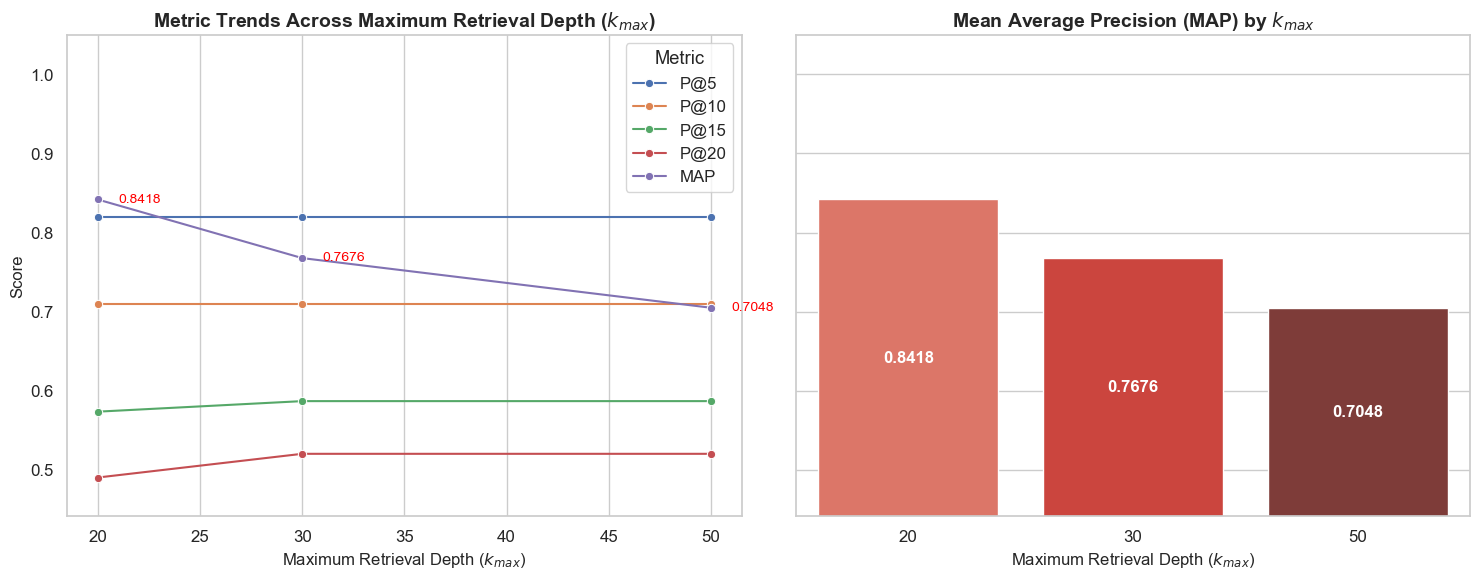

In [147]:
visualize_metrics(dynamic_df)